In [1]:
import os
os.environ['JULIA_NUM_THREADS'] = '1'
os.environ['JULIA_DEPOT_PATH'] = '/pscratch/sd/s/sferrett/.julia'
os.environ['PYTHON_JULIAPKG_PROJECT'] = '/pscratch/sd/s/sferrett/.julia/environments/pyjuliapkg'

import gc
import sys
sys.path.insert(0,os.path.abspath('..'))

import json
import time
import pickle
import shutil
import tempfile
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import proplot as pplt
from pysr import PySRRegressor,jl
from scripts.data.classes import PredictionWriter
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})
jl.seval('safe_pow(x, y) = abs(x)^y')

/global/homes/s/sferrett/.conda/envs/monsoon-discovery/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


safe_pow (generic function with 1 method)

In [2]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)

SPLITSDIR    = CONFIGS['filepaths']['splits']
PREDSDIR     = CONFIGS['filepaths']['predictions']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
TARGETVAR    = CONFIGS['variables']['target']
SRRUNS       = CONFIGS['experiments']['sr']['runs']
RUNNAME      = list(SRRUNS.keys())[0]
RUNCONFIG    = SRRUNS[RUNNAME]
FIELDVARS    = RUNCONFIG['fieldvars']
LOCALVARS    = RUNCONFIG['localvars']
FEATSFROM    = RUNCONFIG.get('featsfrom',None)
PREDICTORS   = FIELDVARS + LOCALVARS
OUTDIR       = os.path.join(MODELSDIR,'sr',RUNNAME)
SUBSETSIZE   = 5000
SEED = 42
SEEDS        = CONFIGS['experiments']['nn']['seeds']
SEARCHMODE   = 'test'

In [3]:
def kernel_integrate(fields,weights,dlev,mask=None):
    weighted = fields * weights[None,:,:] * dlev[None,None,:]
    if mask is not None:
        weighted = weighted * mask[:,None,:]
    return weighted.sum(axis=2)

def load_split(splitname,fieldvars,localvars,targetvar,splitsdir,
               weightsdir=None,featsfrom=None,seeds=None):
    splitpath = os.path.join(splitsdir,f'norm_{splitname}.h5')
    splitds   = xr.open_dataset(splitpath,engine='h5netcdf')
    refda = splitds[targetvar].transpose('time','lat','lon')
    ntime = splitds.sizes['time']
    columns = {}
    if featsfrom:
        nlevs = splitds.sizes['lev']
        dlev  = splitds['dlev'].values
        fieldarrays = []
        for var in fieldvars:
            da = splitds[var].transpose('time','lat','lon','lev')
            fieldarrays.append(da.values.reshape(-1,nlevs))
        fields3d = np.stack(fieldarrays,axis=1)
        mask = splitds['surfmask'].transpose('time','lat','lon','lev').values.reshape(-1,nlevs)
        seedfeats = []
        for seed in seeds:
            wpath   = os.path.join(weightsdir,f'{featsfrom}_{seed}_weights.nc')
            wds     = xr.open_dataset(wpath,engine='h5netcdf')
            weights = wds['k1'].isel(seed=0).values
            wds.close()
            seedfeats.append(kernel_integrate(fields3d,weights,dlev,mask))
        feats = np.mean(seedfeats,axis=0)
        for i,var in enumerate(fieldvars):
            columns[var] = feats[:,i]
    else:
        for var in fieldvars:
            da = splitds[var]
            if 'time' in da.dims:
                arr = da.transpose('time','lat','lon').values
            else:
                arr = np.tile(da.values,(ntime,1,1))
            columns[var] = arr.ravel()
    for var in localvars:
        da = splitds[var]
        if 'time' in da.dims:
            arr = da.transpose('time','lat','lon').values
        else:
            arr = np.tile(da.values,(ntime,1,1))
        columns[var] = arr.ravel()
    X = pd.DataFrame(columns)
    y = refda.values.ravel()
    validmask = np.isfinite(X).all(axis=1).values & np.isfinite(y)
    splitds.close()
    return X,y,refda,validmask

In [4]:
scalarcols  = {}
targets     = []
profilerows = []
maskrows    = []
dlevvals    = None

for splitname in ('train','valid'):
    splitpath = os.path.join(SPLITSDIR,f'norm_{splitname}.h5')
    with xr.open_dataset(splitpath,engine='h5netcdf') as splitds:
        ntime = splitds.sizes['time']
        targets.append(splitds[TARGETVAR].transpose('time','lat','lon').values.ravel())
        for var in LOCALVARS:
            da  = splitds[var]
            arr = da.transpose('time','lat','lon').values if 'time' in da.dims else np.tile(da.values,(ntime,1,1))
            scalarcols.setdefault(var,[]).append(arr.ravel())
        if FEATSFROM:
            nlevs    = splitds.sizes['lev']
            dlevvals = splitds['dlev'].values
            fieldarrays = []
            for var in FIELDVARS:
                da = splitds[var].transpose('time','lat','lon','lev')
                fieldarrays.append(da.values.reshape(-1,nlevs))
            profilerows.append(np.stack(fieldarrays,axis=1))
            maskrows.append(splitds['surfmask'].transpose('time','lat','lon','lev').values.reshape(-1,nlevs))
        else:
            for var in FIELDVARS:
                da  = splitds[var]
                arr = da.transpose('time','lat','lon').values if 'time' in da.dims else np.tile(da.values,(ntime,1,1))
                scalarcols.setdefault(var,[]).append(arr.ravel())

yfit    = np.concatenate(targets)
fitcols = {k:np.concatenate(v) for k,v in scalarcols.items()}
fitdf   = pd.DataFrame(fitcols)
fitdf['__target__'] = yfit
fitdf   = fitdf.replace([np.inf,-np.inf],np.nan).dropna()
keepidx = fitdf.index.values
yfit    = fitdf.pop('__target__').values

rng       = np.random.default_rng(SEED)
sortedidx = np.argsort(yfit)
bins      = np.array_split(sortedidx,SUBSETSIZE)
subidx    = np.array([rng.choice(b) for b in bins if len(b)>0])
print(f'Stratified subsample: {len(subidx)} from {len(yfit)} clean train+valid points')

Xsub = fitdf.iloc[subidx].reset_index(drop=True)
ysub = yfit[subidx]

if FEATSFROM:
    allprofiles = np.concatenate(profilerows,axis=0)
    allmasks    = np.concatenate(maskrows,axis=0)
    subprofiles = allprofiles[keepidx[subidx]]
    submasks    = allmasks[keepidx[subidx]]
    seedfeats   = []
    for seed in SEEDS:
        wpath = os.path.join(WEIGHTSDIR,f'{FEATSFROM}_{seed}_weights.nc')
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            weights = wds['k1'].isel(seed=0).values
        seedfeats.append(kernel_integrate(subprofiles,weights,dlevvals,submasks))
    feats = np.mean(seedfeats,axis=0)
    for i,var in enumerate(FIELDVARS):
        Xsub.insert(i,var,feats[:,i])
    del allprofiles,allmasks,subprofiles,submasks,profilerows,maskrows

print(f'Xsub: {Xsub.shape}, ysub: {ysub.shape}')
print(f'\nXsub summary:\n{Xsub.describe()}')
print(f'\nysub: mean={ysub.mean():.6f}, std={ysub.std():.6f}, min={ysub.min():.6f}, max={ysub.max():.6f}')

Stratified subsample: 5000 from 8624448 clean train+valid points
Xsub: (5000, 1), ysub: (5000,)

Xsub summary:
                bl
count  5000.000000
mean     -0.008694
std       1.029029
min      -6.340377
25%      -0.274762
50%       0.285133
75%       0.641442
max       1.405270

ysub: mean=-0.004298, std=0.996517, min=-0.638929, max=6.709570


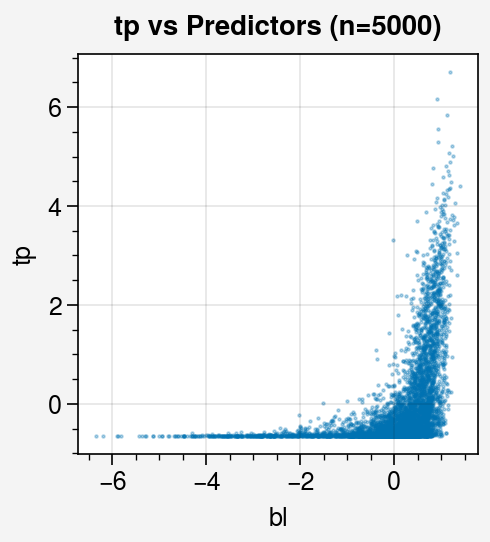

In [5]:
# nvars = len(PREDICTORS)
# fig,axes = pplt.subplots(ncols=nvars,refwidth=2,refheight=2,sharex=False,sharey=True)
# for i,var in enumerate(PREDICTORS):
#     ax = axes[i]
#     ax.scatter(Xsub[var],ysub,s=1,alpha=0.3)
#     ax.format(xlabel=var,ylabel=TARGETVAR if i==0 else '')
# fig.suptitle(f'{TARGETVAR} vs Predictors (n={len(ysub)})')
# pplt.show()

In [6]:
opcomplexity = {'+':1,'-':1,'*':1,'/':3,'safe_pow':3,'exp':4,'log':4}

searchparams = {
    'test':  dict(niterations=5,          populations=5,  population_size=33,  maxsize=15, procs=0,  timeout_in_seconds=300),
    'medium':dict(niterations=100,         populations=20, population_size=50,  maxsize=30, procs=20, timeout_in_seconds=1800),
    'full':  dict(niterations=10_000_000,  populations=30, population_size=100, maxsize=50, procs=30, timeout_in_seconds=int(60*60*7.5)),
}

params = searchparams[SEARCHMODE]
print(f'Search mode: {SEARCHMODE}')
print(f'Parameters: {params}')

Search mode: test
Parameters: {'niterations': 5, 'populations': 5, 'population_size': 33, 'maxsize': 15, 'procs': 0, 'timeout_in_seconds': 300}


In [7]:
os.makedirs(OUTDIR,exist_ok=True)
TMPDIR = tempfile.mkdtemp(prefix='pysr_')

model = PySRRegressor(
    niterations=params['niterations'],
    populations=params['populations'],
    population_size=params['population_size'],
    binary_operators=['+','-','*','/','safe_pow'],
    unary_operators=['exp','log'],
    complexity_of_operators=opcomplexity,
    complexity_of_variables=2,
    complexity_of_constants=1,
    maxsize=params['maxsize'],
    maxdepth=4,
    constraints={'safe_pow':(-1,1)},
    nested_constraints={
        'exp':{'exp':0,'log':0,'safe_pow':0},
        'safe_pow':{'safe_pow':0},
        'log':{'log':0,'exp':0}},
    extra_sympy_mappings={'safe_pow':lambda x,y:x**y},
    loss='loss(x, y) = (x - y)^2',
    model_selection='best',
    batching=len(ysub)>2000,
    batch_size=min(2000,len(ysub)),
    random_state=SEED,
    deterministic=True,
    multithreading=False,
    procs=params['procs'],
    tempdir=TMPDIR,
    temp_equation_file=True,
    delete_tempfiles=True,
    timeout_in_seconds=params['timeout_in_seconds'],
    progress=True)

In [ ]:
import threading
t0    = time.time()
done  = threading.Event()
err   = [None]
def _fit():
    try:
        model.fit(Xsub.values,ysub,variable_names=PREDICTORS)
    except Exception as e:
        err[0] = e
    finally:
        done.set()
threading.Thread(target=_fit,daemon=True).start()
while not done.wait(timeout=30):
    print(f'  ...{(time.time()-t0)/60:.1f} min elapsed',flush=True)
if err[0]:
    raise err[0]
elapsed = time.time()-t0

shutil.rmtree(TMPDIR,ignore_errors=True)
print(f'\nSearch completed in {elapsed/60:.1f} minutes')
print(model)

In [ ]:
equations = model.equations_
print(equations[['equation','complexity','loss','score']].to_string())

In [ ]:
besteq = model.get_best()
msesub = np.mean((ysub-model.predict(Xsub.values))**2)

Xtest,ytest,refdatest,validtest = load_split('test',FIELDVARS,LOCALVARS,TARGETVAR,SPLITSDIR,WEIGHTSDIR,FEATSFROM,SEEDS)
Xtest = Xtest[validtest].reset_index(drop=True)
ytest = ytest[validtest]
ypredtest = model.predict(Xtest.values)
msetest = np.mean((ytest-ypredtest)**2)

print(f'Best equation: {besteq["equation"]}')
print(f'  Complexity:   {besteq["complexity"]}')
print(f'  MSE fit subset: {msesub:.6f}')
print(f'  MSE test:       {msetest:.6f}')

In [ ]:
fig,ax = pplt.subplots(refwidth=5,refheight=3.5)
ax.scatter(equations['complexity'],equations['loss'],zorder=5)
ax.format(xlim=(0,equations['complexity'].max()+3),
          ylim=(equations['loss'].min()*0.9,equations['loss'].max()*1.1),
          xlabel='Complexity',ylabel='MSE Loss',
          title='Pareto Frontier of Discovered Equations')
for i,row in equations.iterrows():
    label = str(row['equation'])[:50]
    ax.annotate(label,xy=(row['complexity'],row['loss']),xytext=(5,5),textcoords='offset points',fontsize=5,clip_on=True)
pplt.show()

In [ ]:
modelpath = os.path.join(OUTDIR,f'{RUNNAME}.pkl')
with open(modelpath,'wb') as f:
    pickle.dump(model,f)
equations.to_csv(os.path.join(OUTDIR,'equations.csv'),index=False)

writer = PredictionWriter(SPLITSDIR,targetvar=TARGETVAR)
predds = writer.predictions_to_dataset([ypredtest],validtest,refdatest)
predds[TARGETVAR] = predds[TARGETVAR].clip(min=0.0)
writer.save(predds,RUNNAME,'predictions','test',PREDSDIR)

print(f'Model saved to: {modelpath}')
print(f'Equations saved to: {os.path.join(OUTDIR,"equations.csv")}')
print(f'Test predictions saved to: {PREDSDIR}')
gc.collect()